In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set()

In [35]:
path= 'household_power_consumption.txt'
data= pd.read_csv('household_power_consumption.txt', sep=';', 
                 na_values='?', low_memory=False)
df= data.copy()

### EDA

In [36]:
df.shape

(2075259, 9)

In [37]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [38]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [39]:
# Combine columns, convert to datetime, and set as index
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df.set_index('Datetime', inplace=True)

In [40]:
df= df.drop(['Date','Time'], axis= 1)

In [41]:
df.head(3)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0


In [42]:
df.isna().sum()

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [43]:
df= df.dropna()

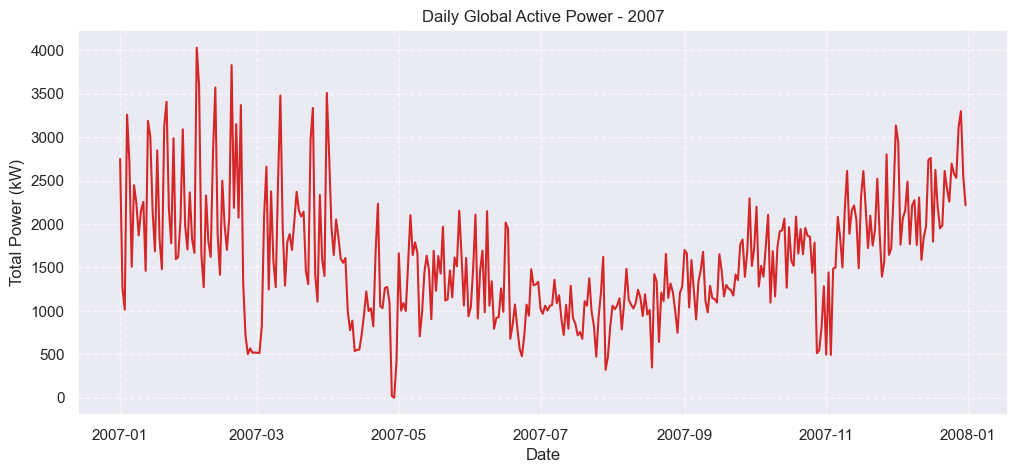

In [48]:
# Resample to Daily ('D') frequency and sum
daily_2007 = df.loc['2007', 'Global_active_power'].resample('D').sum()

# Explicit control with figure
plt.figure(figsize=(12, 5))
plt.plot(daily_2007.index, daily_2007.values, color='tab:red', linewidth=1.5)

plt.title('Daily Global Active Power - 2007')
plt.xlabel('Date')
plt.ylabel('Total Power (kW)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

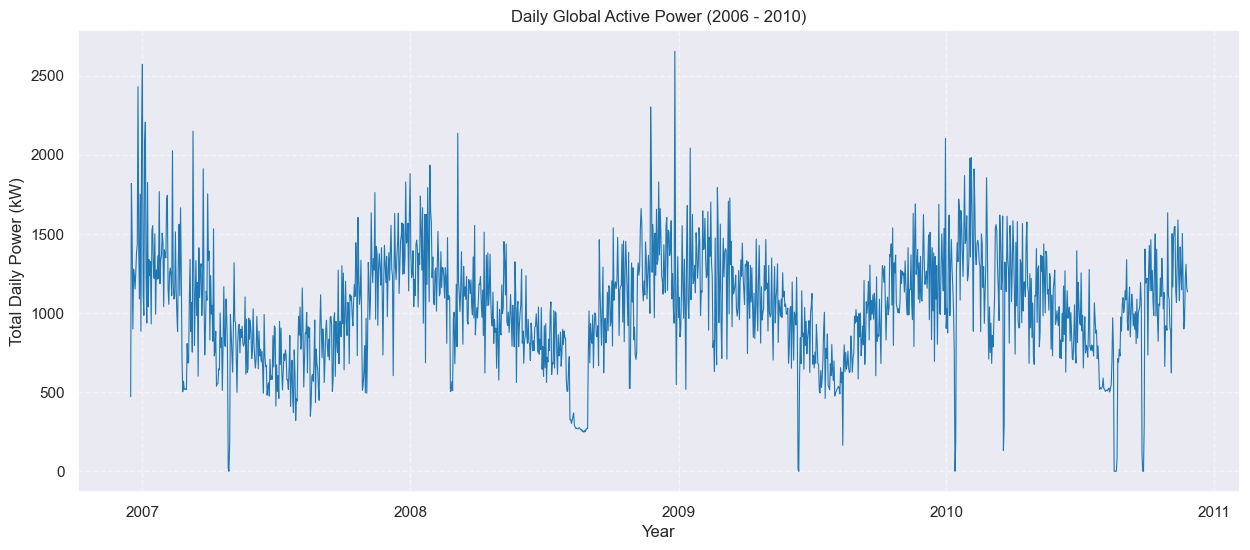

In [60]:
import matplotlib.dates as mdates
df_daily = df['Global_active_power'].resample('D').sum()
plt.figure(figsize=(15, 6))
plt.plot(df_daily.index, df_daily.values, color='tab:blue', linewidth=0.8)

# Set x-axis to only show the Year
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title('Daily Global Active Power (2006 - 2010)')
plt.xlabel('Year')
plt.ylabel('Total Daily Power (kW)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [59]:
df.describe().round(2)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,1760881.00,1760881.00,1760881.00,1760881.00,1760881.0,1760881.00,1760881.00
mean,0.84,0.11,241.10,3.58,0.0,0.34,5.72
std,0.71,0.10,3.02,2.94,0.0,0.62,8.16
min,0.08,0.00,223.99,0.20,0.0,0.00,0.00
25%,0.29,0.05,239.39,1.20,0.0,0.00,0.00
50%,0.45,0.10,241.25,2.00,0.0,0.00,1.00
75%,1.39,0.18,243.04,5.80,0.0,1.00,17.00
max,3.36,0.41,248.73,13.80,0.0,2.00,31.00


In [57]:
outlier_indicies= []
for col in df.columns:

    Q1= df[col].quantile(.25)
    Q3= df[col].quantile(.75)

    IQR= Q3 - Q1
    upper= Q3 + 1.5*IQR
    mask= df[col] > upper
    outlier_indicies.extend(df[mask].index)
df= df.drop(list(set(outlier_indicies)))

In [63]:
from statsmodels.tsa.stattools import adfuller

# 2. Run the test
result = adfuller(df_daily)

print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -3.828649903640002
p-value: 0.0026274213073607345


### Preprocessing

In [71]:
df_daily.shape

(1442,)

In [73]:
df_daily = df.resample('D').sum()
# 1. Define Target and Exogenous features
y = df_daily['Global_active_power']
X = df_daily[['Global_reactive_power', 'Voltage', 'Global_intensity', 
              'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']]

# 2. Split by date (Training: 2006-2009 | Testing: 2010)
train_y = y.loc[:'2009-12-31']
test_y  = y.loc['2010-01-01':]

train_X = X.loc[:'2009-12-31']
test_X  = X.loc['2010-01-01':]

### Model Selection

In [74]:
import pmdarima as pm

# Fit the model
# m=7 handles weekly seasonality (power usage usually differs on weekends)
model = pm.auto_arima(train_y, 
                      X=train_X,
                      seasonal=True, 
                      m=7, 
                      stepwise=True, 
                      suppress_warnings=True, 
                      error_action='ignore', 
                      trace=True)

# Print the best model summary
print(f"Best Model: {model.order} x {model.seasonal_order}")
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=8434.799, Time=2.76 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=9123.340, Time=0.29 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=8643.078, Time=0.82 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=8756.866, Time=1.41 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=15809.823, Time=0.25 sec
 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=8458.272, Time=1.63 sec
 ARIMA(2,0,2)(1,0,0)[7] intercept   : AIC=8504.367, Time=1.69 sec
 ARIMA(2,0,2)(2,0,1)[7] intercept   : AIC=8432.646, Time=4.73 sec
 ARIMA(2,0,2)(2,0,0)[7] intercept   : AIC=8487.183, Time=4.02 sec
 ARIMA(2,0,2)(2,0,2)[7] intercept   : AIC=8433.362, Time=6.47 sec
 ARIMA(2,0,2)(1,0,2)[7] intercept   : AIC=8432.658, Time=10.08 sec
 ARIMA(1,0,2)(2,0,1)[7] intercept   : AIC=8428.881, Time=3.28 sec
 ARIMA(1,0,2)(1,0,1)[7] intercept   : AIC=8434.286, Time=2.36 sec
 ARIMA(1,0,2)(2,0,0)[7] intercept   : AIC=8484.381, Time=3.02 sec
 ARIMA(1,0,2)(2,0,2)[7] interce

### Model Eval

In [84]:
print(f"Best Model: {model.order} x {model.seasonal_order}")
# Extract name from the underlying statsmodels object
model_name = model.arima_res_.__class__.__name__
print(f"Model Type: {model_name}")

Best Model: (1, 0, 2) x (1, 0, 2, 7)
Model Type: SARIMAXResultsWrapper


In [75]:
from sklearn.metrics import root_mean_squared_error
predictions = model.predict(n_periods=len(test_y), X=test_X)
rmse= root_mean_squared_error(test_y, predictions)
print('RMSE:',rmse)

RMSE: 15.400727997354995


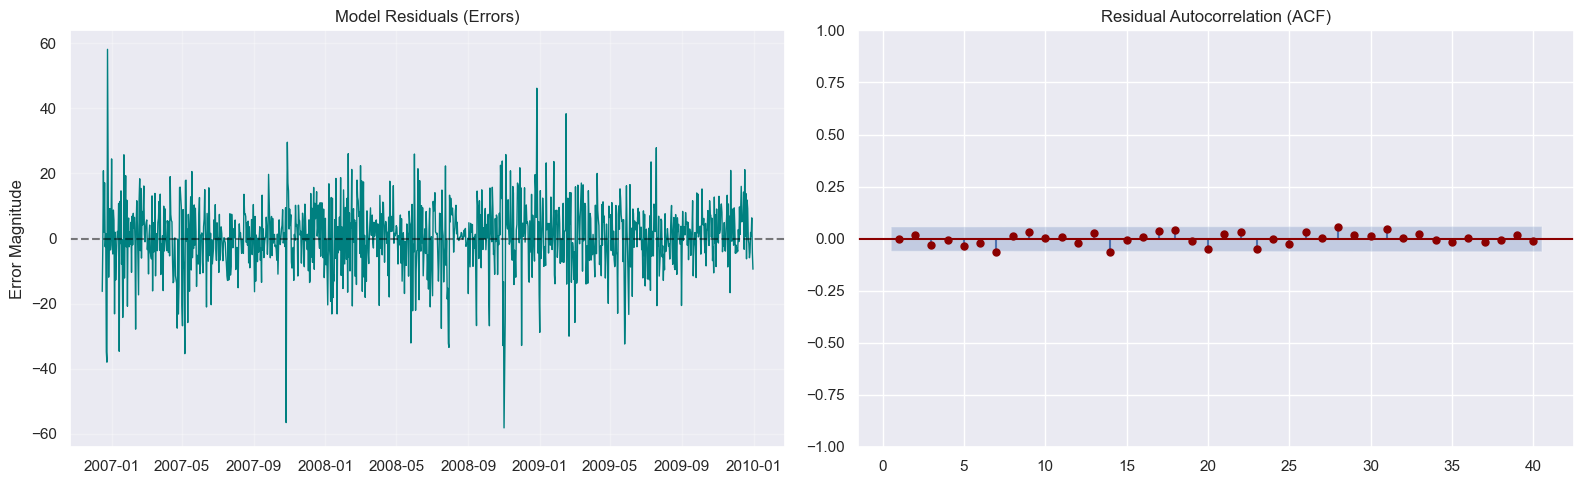

In [77]:
from statsmodels.graphics.tsaplots import plot_acf

# 1. Obtain residuals from the fitted model
residuals = model.resid()

# 2. Create a 1x2 subplot
plt.figure(figsize=(16, 5))

# Left Subplot: Residuals Over Time
plt.subplot(1, 2, 1)
plt.plot(residuals, color='teal', linewidth=1)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Model Residuals (Errors)')
plt.ylabel('Error Magnitude')
plt.grid(True, alpha=0.3)

# Right Subplot: ACF of Residuals
ax2 = plt.subplot(1, 2, 2)
plot_acf(residuals, ax=ax2, lags=40, color='darkred', zero= False)
plt.title('Residual Autocorrelation (ACF)')

plt.tight_layout()
plt.show()

In [85]:
from statsmodels.stats.diagnostic import het_arch

# Run the ARCH LM Test
# residuals were obtained from model.resid()
lm_test = het_arch(residuals)

print(f'LM Statistic: {lm_test[0]}')
print(f'p-value: {lm_test[1]}')

LM Statistic: 67.63521409505195
p-value: 1.2659397932339544e-10


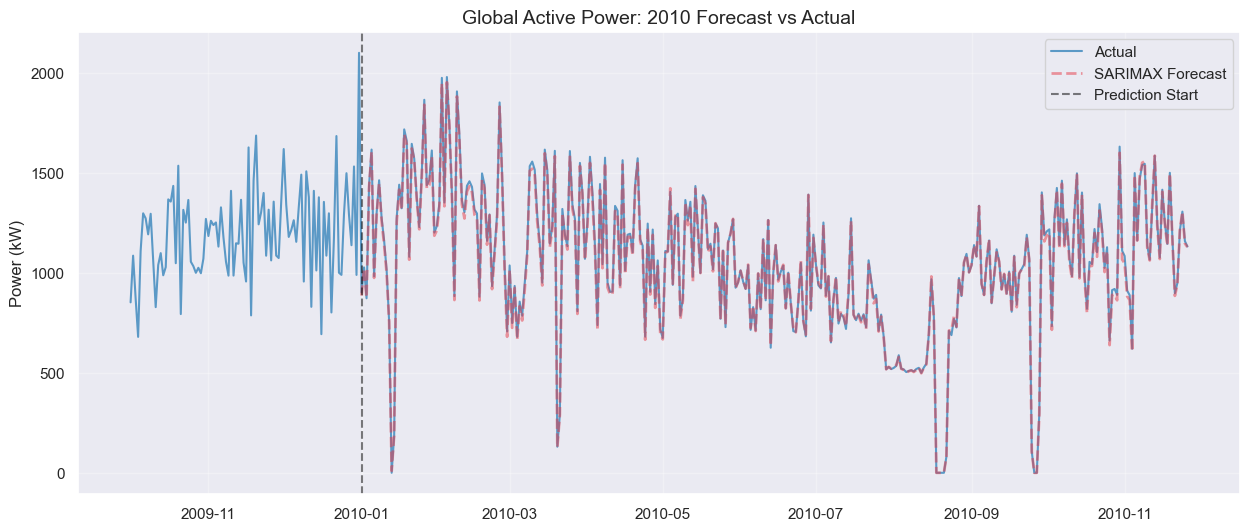

In [89]:
import matplotlib.pyplot as plt

# 1. Generate predictions for 2010
forecast = model.predict(n_periods=len(test_y), X=test_X)
forecast_series = pd.Series(forecast, index=test_y.index)

# 2. Slice data to show context (Oct 2009 onwards)
actual_plot = y.loc['2009-10-01':]

# 3. Create the plot
plt.figure(figsize=(15, 6))

# Plot actual values
plt.plot(actual_plot.index, actual_plot.values, label='Actual', color='#1f77b4', alpha=0.7)

# Plot predicted values for 2010
plt.plot(forecast_series.index, forecast_series.values, label='SARIMAX Forecast', color='#e63946', linewidth=2, alpha=0.5, linestyle='--')

# Styling
plt.title('Global Active Power: 2010 Forecast vs Actual', fontsize=14)
plt.axvline(pd.Timestamp('2010-01-01'), color='black', linestyle='--', alpha=0.5, label='Prediction Start')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Forecasting

### Volatility capturing

In [90]:
from arch import arch_model

# 1. Scale residuals for better convergence
resids = model.resid() * 10 

# 2. Define the GARCH(1,1) model
# p=1: Lagged variance (GARCH term)
# q=1: Lagged squared error (ARCH term)
garch_model = arch_model(resids, p=1, q=1, vol='Garch', dist='normal')

# 3. Fit the model
garch_result = garch_result = garch_model.fit(disp='off')

print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6702.54
Distribution:                  Normal   AIC:                           13413.1
Method:            Maximum Likelihood   BIC:                           13433.1
                                        No. Observations:                 1112
Date:                Tue, Feb 03 2026   Df Residuals:                     1111
Time:                        19:40:43   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             2.4352      2.959      0.823      0.410 [ -3.363,  8.23

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.115e+04. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


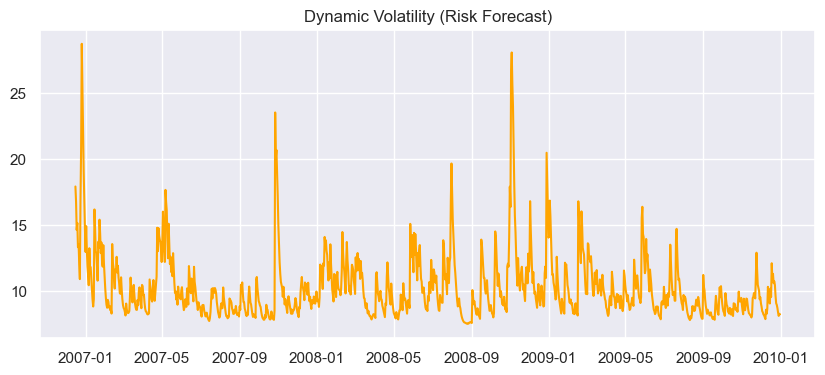

In [91]:
# Extract conditional volatility
volatility = garch_result.conditional_volatility / 10 # Scale back down

plt.figure(figsize=(10, 4))
plt.plot(volatility, color='orange')
plt.title('Dynamic Volatility (Risk Forecast)')
plt.show()

### Combinig models

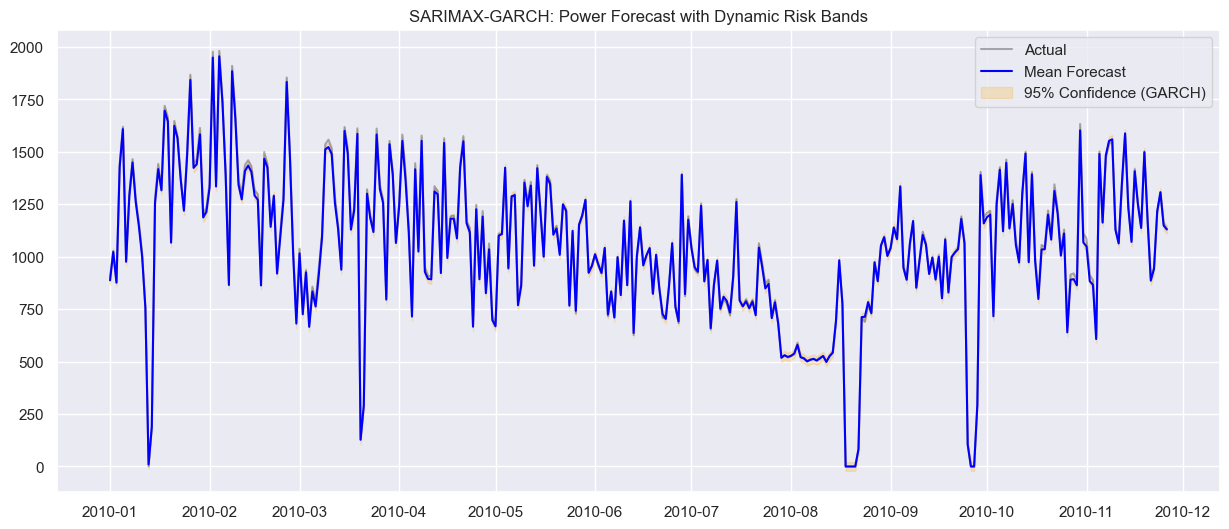

In [93]:
# 1. SARIMAX Point Forecast (The Mean)
mu_forecast = model.predict(n_periods=len(test_y), X=test_X)

# 2. GARCH Volatility Forecast (The Risk)
# We forecast the variance for the test period
garch_forecast = garch_result.forecast(horizon=len(test_y))
# Extract standard deviation (volatility) and scale back
cond_vol = np.sqrt(garch_forecast.variance.values[-1, :]) / 10 

# 3. Calculate 95% Prediction Interval
# Using the formula: Mean ± (1.96 * Volatility)
upper_bound = mu_forecast + (1.96 * cond_vol)
lower_bound = mu_forecast - (1.96 * cond_vol)

# 4. Visualization
plt.figure(figsize=(15, 6))
plt.plot(test_y.index, test_y.values, label='Actual', color='black', alpha=0.3)
plt.plot(test_y.index, mu_forecast, label='Mean Forecast', color='blue')
plt.fill_between(test_y.index, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% Confidence (GARCH)')
plt.title('SARIMAX-GARCH: Power Forecast with Dynamic Risk Bands')
plt.legend()
plt.show()

In [95]:
# 1. Recursive Forecast (Static)
mu_rec = model.predict(n_periods=len(test_y), X=test_X)
garch_rec = garch_result.forecast(horizon=len(test_y))
vol_rec = np.sqrt(garch_rec.variance.values[-1, :]) / 10

# 2. Optimized Rolling Forecast (Dynamic)
mu_roll = []
# Create a copy of the model to avoid altering the original 'model' object
model_rolling = model 

for i in range(len(test_y)):
    # Predict next step
    pred = model_rolling.predict(n_periods=1, X=test_X.iloc[[i]])
    mu_roll.append(pred[0])
    
    # Update model state with actual data WITHOUT full refitting (maxiter=0)
    model_rolling.update(test_y.iloc[[i]], X=test_X.iloc[[i]], maxiter=0)

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# Graph 1: Recursive
ax1.plot(test_y.index, test_y, color='black', alpha=0.3, label='Actual')
ax1.plot(test_y.index, mu_rec, color='blue', label='Recursive')
ax1.fill_between(test_y.index, mu_rec - 1.96*vol_rec, mu_rec + 1.96*vol_rec, color='orange', alpha=0.2)
ax1.set_title("Recursive Forecast: Entire Year at Once")
ax1.legend()

# Graph 2: Rolling
ax2.plot(test_y.index, test_y, color='black', alpha=0.3, label='Actual')
ax2.plot(test_y.index, mu_roll, color='green', label='Rolling')
ax2.fill_between(test_y.index, np.array(mu_roll) - 1.96*vol_rec, np.array(mu_roll) + 1.96*vol_rec, color='orange', alpha=0.2)
ax2.set_title("Rolling Forecast: Updated Daily (Optimized)")
ax2.legend()

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
import pandas as pd

# 1. Combine SARIMAX mean and GARCH volatility into a DataFrame
report_df = pd.DataFrame({
    'Mean_Forecast': mu_forecast,
    'Volatility_Sigma': cond_vol
}, index=test_y.index)

# 2. Resample to Monthly frequency ('M')
# Total_Volume: How much coal to buy
# Peak_Demand: Highest stress on the system
# Risk_Buffer: Extra 'safety' coal to keep in stock (95% confidence)
exec_table = report_df.resample('M').agg({
    'Mean_Forecast': ['sum', 'max'],
    'Volatility_Sigma': 'sum'
})

# 3. Clean up column names and calculate Max Potential Need
exec_table.columns = ['Total_Volume_kW', 'Peak_Demand_kW', 'Total_Volatility']
exec_table['95%_Risk_Buffer_kW'] = exec_table['Total_Volatility'] * 1.96
exec_table['Max_Potential_Need_kW'] = exec_table['Total_Volume_kW'] + exec_table['95%_Risk_Buffer_kW']

# Format index to Month Names for readability
exec_table.index = exec_table.index.strftime('%B %Y')

# Display the report
print(exec_table[['Total_Volume_kW', 'Peak_Demand_kW', '95%_Risk_Buffer_kW', 'Max_Potential_Need_kW']])

# Save for excel
exec_table.to_csv('executive_monthly_plan_2010.csv')